In [30]:
import os
import json
from tqdm import tqdm
import numpy as np
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torch.utils.data import Subset, DataLoader
from torch.utils.data import Dataset
import torchvision.transforms as T
import torchvision.transforms as transforms
from torchvision.transforms import ToPILImage
from torchvision.utils import save_image
import matplotlib.pyplot as plt
import random

import sys
#sys.path.append("/teamspace/studios/this_studio/Deep-Learning")

from dataset import Edges2ShoesDataset
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Data Loading

In [2]:
# display the contents in the data folder 
data_path = "/teamspace/studios/this_studio/data"
os.listdir(data_path)

['test', 'train']

In [3]:
train_dataset = Edges2ShoesDataset(
    root_dir=data_path,
    phase="train",
    image_size=256 #resize the input images to 256 to match the input dimensions expected from the DiT-XL-256 model and itis more computationally efficient
)

test_dataset = Edges2ShoesDataset(
    root_dir=data_path,
    phase="test",
    image_size=256 #resize the input images to 256 to match the input dimensions expected from the DiT-XL-256 model and itis more computationally efficient
    
)

print(f"The size of the training set = {len(train_dataset)}")
print(f"The size of the testing set = {len(test_dataset)}")

The size of the training set = 10000
The size of the testing set = 1000


In [4]:
batch_size = 8

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size, 
    shuffle=True
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    shuffle=True
)

In [5]:
# The dataset class returns 3 inputs which are edge image, shoe image, and captions that describe the shoe image
batch = next(iter(train_loader))
print(batch.keys())

dict_keys(['shoe', 'edge'])


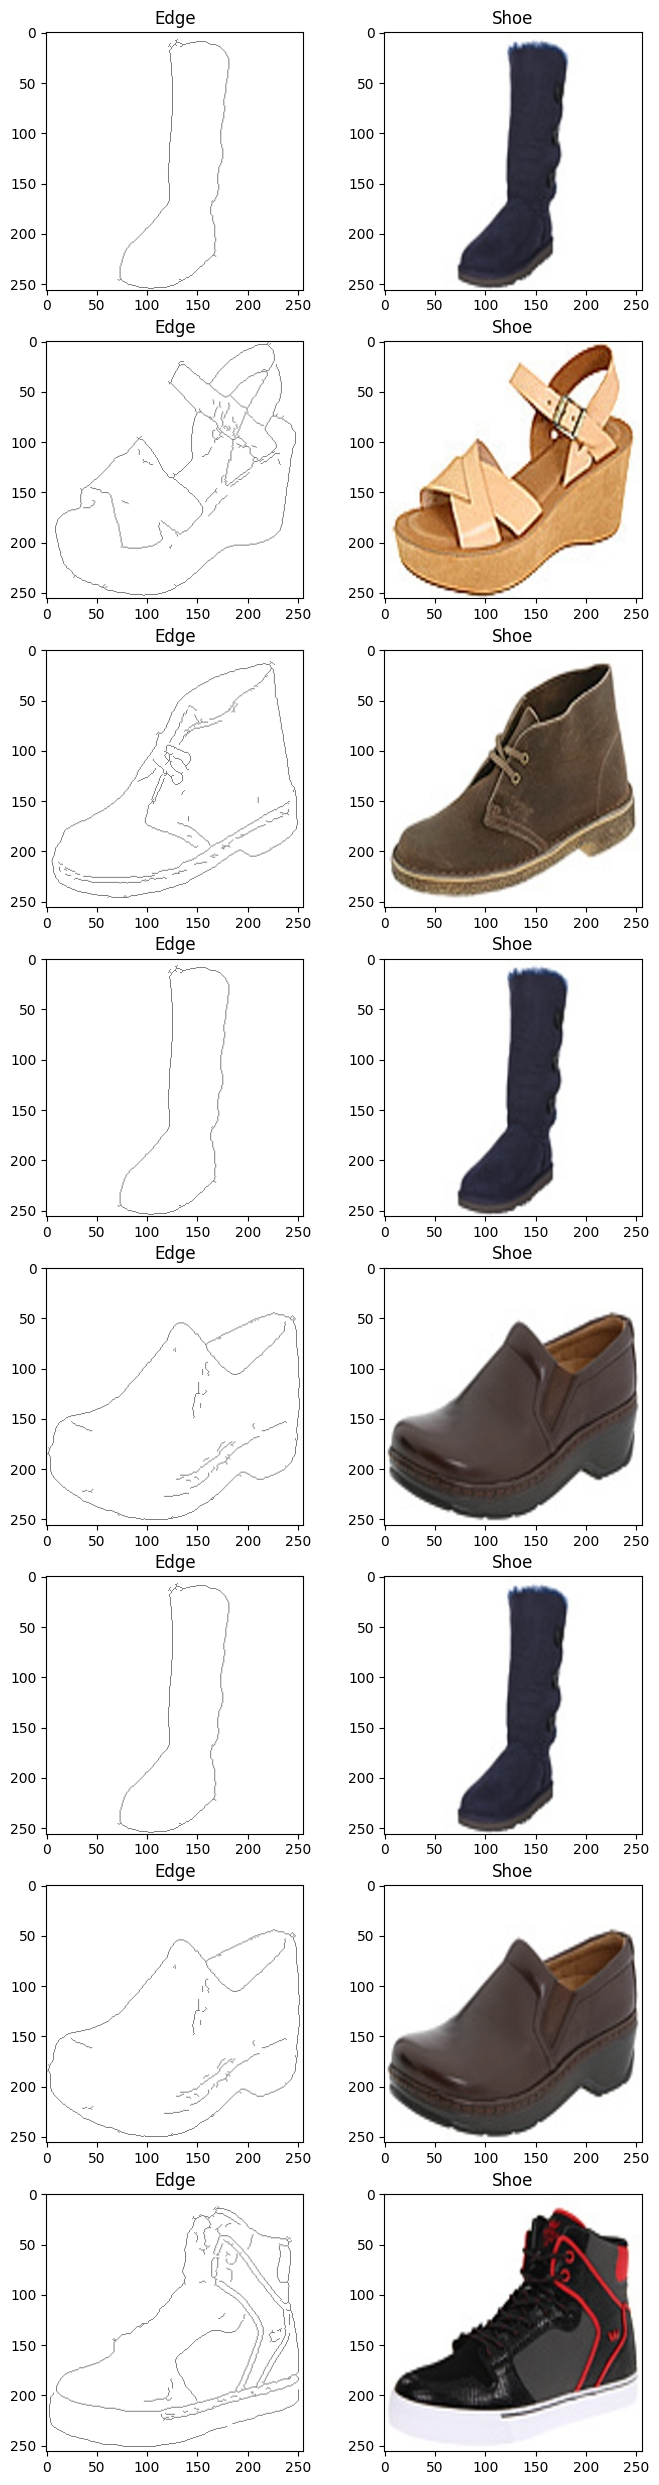

In [6]:
# diplaying a batch from the dataset
plt.figure(figsize=(8, 256))

for i in range(8):
    num = random.randint(0, batch_size-1)
    
    edge = (batch["edge"][num] * 0.5) + 0.5
    shoe = (batch["shoe"][num] * 0.5) + 0.5
    
    plt.subplot(64, 2, 2*i + 1)
    plt.title("Edge")
    plt.imshow(edge.permute(1,2,0))

    plt.subplot(64, 2, 2*i + 2)
    plt.title("Shoe")
    plt.imshow(shoe.permute(1,2,0))

plt.show()

# Diffusion Transformer

In [7]:
from diffusers import AutoencoderKL, DDPMScheduler
import clip
path = "runwayml/stable-diffusion-v1-5"

## VAE

### Why to use VAE?
- The VAE used to enable the diffusion transformer model working on the latent space rather that the pixel space to save memory and speed up the training.
- VAE will be used during training to encode images and pass their latent representations to the diffusion model that will work on these latent representations.
- After the diffusion model finishes the denoising steps and generates the pure latent representations, it will be passed to the decoder of the VAE to reconstrct the image from these latents.

In [8]:
# load the VAE
vae = AutoencoderKL.from_pretrained(
    path,
    subfolder="vae"
)
vae = vae.to(device)

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


In [9]:
# This function uses the encoder of the VAE and it takes an image as an input then return its latent representations
def encode_img(img):
    with torch.no_grad():
        latents = vae.encode(img) # Get the latent representations of the image
        latents = latents.latent_dist.sample() # Take a sample from the distribution of the latent space of the VAE
        latents = latents * vae.config.scaling_factor # scale the latents 
    return latents

In [10]:
# This function uses the VAE decoder, it takes as input a latent representations of an image then it reconstruct this image from its latent representation and return the image
def decode_latents(latents):
    with torch.no_grad():
        recon_img = vae.decode(latents / vae.config.scaling_factor).sample # return the latent representations to its original scale then reconstruct it
    return recon_img

### Testing the reconstruction ability of the VAE to make sure itis working properly
- Load a sample from the dataset (Edge and Shoe)
- I will encode these 2 images using the encode_img function
- Then I will use the decode_latents function to reconstruct the original images
- Then plot the results (Original images and Reconstructed images)

In [11]:
edge_img = batch["edge"][0]
edge_img = edge_img.unsqueeze(0) # preparing the image for the expected dimensions [B, C, H, W] in the VAE by adding the batch size
edge_img = edge_img.to(device)

shoe_img = batch["shoe"][0] 
shoe_img = shoe_img.unsqueeze(0) # preparing the image for the expected dimensions [B, C, H, W] in the VAE by adding the batch size
shoe_img = shoe_img.to(device)

In [12]:
# Encode edge image
edge_latents = encode_img(edge_img)
print(f"Latent Representations Shape: {edge_latents.shape}")

# Encode shoe image
shoe_latents = encode_img(shoe_img)
print(f"Latent Representations Shape: {shoe_latents.shape}")

Latent Representations Shape: torch.Size([1, 4, 32, 32])
Latent Representations Shape: torch.Size([1, 4, 32, 32])


In [13]:
# Reconstruct edge image
recon_edge = decode_latents(edge_latents)
print(f"Reconstructed Edge Image Shape: {recon_edge.shape}")

# Reconstruct shoe image
recon_shoe = decode_latents(shoe_latents)
print(f"Reconstructed Shoe Image Shape: {recon_shoe.shape}")

Reconstructed Edge Image Shape: torch.Size([1, 3, 256, 256])
Reconstructed Shoe Image Shape: torch.Size([1, 3, 256, 256])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


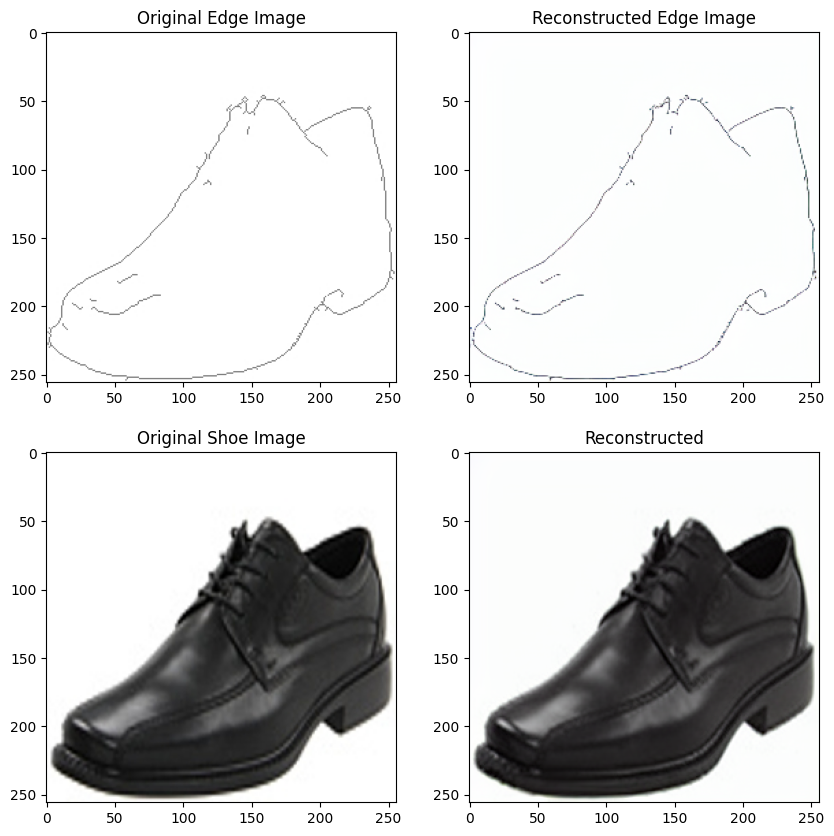

In [14]:
plt.figure(figsize=(10,10))

plt.subplot(2,2,1)
plt.title("Original Edge Image")
edge_img = edge_img.squeeze(0) # prepare the image for the expected dimensions in matplotlib (removing the channel that represent the size of batch)
edge_img = edge_img * 0.5 + 0.5 
plt.imshow(edge_img.permute(1,2,0).cpu())

plt.subplot(2,2,2)
plt.title("Reconstructed Edge Image")
recon_edge = recon_edge.squeeze(0)
recon_edge = recon_edge * 0.5 + 0.5
plt.imshow(recon_edge.permute(1,2,0).cpu())

plt.subplot(2,2,3)
plt.title("Original Shoe Image")
shoe_img = shoe_img.squeeze(0)
shoe_img = shoe_img * 0.5 + 0.5
plt.imshow(shoe_img.permute(1,2,0).cpu())

plt.subplot(2,2,4)
plt.title("Reconstructed")
recon_shoe = recon_shoe.squeeze(0)
recon_shoe = recon_shoe * 0.5 + 0.5
plt.imshow(recon_shoe.permute(1,2,0).cpu())

plt.show()

## Noise Scheduler

### Why using Noise Scheduler?
- It will be used to add noise to the latent representations of the images in the forward diffusion process
- And performing denoising steps with the predicted noise values from the diffuwion model in the backward diffusion process

In [15]:
noise_scheduler = DDPMScheduler(
    num_train_timesteps=1000
)

## Base DiT Model

In [ ]:
!git clone https://github.com/facebookresearch/DiT.git

In [16]:
# importing the original pretrained DiT model
from DiT.models import DiT_XL_2
DiT = DiT_XL_2(input_size=32).to(device)
DiT

DiT(
  (x_embedder): PatchEmbed(
    (proj): Conv2d(4, 1152, kernel_size=(2, 2), stride=(2, 2))
    (norm): Identity()
  )
  (t_embedder): TimestepEmbedder(
    (mlp): Sequential(
      (0): Linear(in_features=256, out_features=1152, bias=True)
      (1): SiLU()
      (2): Linear(in_features=1152, out_features=1152, bias=True)
    )
  )
  (y_embedder): LabelEmbedder(
    (embedding_table): Embedding(1001, 1152)
  )
  (blocks): ModuleList(
    (0-27): 28 x DiTBlock(
      (norm1): LayerNorm((1152,), eps=1e-06, elementwise_affine=False)
      (attn): Attention(
        (qkv): Linear(in_features=1152, out_features=3456, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (norm): Identity()
        (proj): Linear(in_features=1152, out_features=1152, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (norm2): LayerNorm((1152,), eps=1e-06, elementwise_affine=False)
      (mlp): Mlp(
        (

The original DiT model expects 3 inputs which are:
- Noisy latent representation of the target image which will be handled by the "x_embedder" block that will split it into patches each patch of size (2x2), then get the embeddings of these patches. 
- Timestep of the noisy image which will be handled by the "t_embedder" block to get the time embeddings.
- The class label of the image which will be the condition that guide the diffusion model and it will be handled by the "y_embedder" block to get the embeddings of the input class label.

But this condition (class label) is not suitable with the task that I'm working on, because all the targets belongs to the same class "Shoe". So, I will modify the architecture so it can work with another type of condition which will be the clip embeddings of the edge image that will be generated using the CLIP image encoder. This type of condition will give the diffusion model semantic information about the target shoe.

This update will be applied through modifying the original DiT architecture by removing the "y_embedder" block and replace it with another block "clip_proj". This block expects the clip embeddings of the edge image as an input then it will project its dimentions to 1152 to match the dimentions of the time embeddings tensor, so together can be injected to the DiT blocks through AdaLN layers.

## DiT First Variation (CLIP Embeddings Conditioning)

### Why Using CLIP?
- It will be used to extract the image embeedings of the edge image
- These embeddings will be the conditions of the diffusion model that enable the model to better preserve structural information and stylistic consistency

In [17]:
# Load pretrained CLIP model
clip_model, preprocess = clip.load("ViT-L/14", device=device)

The preprocess that returned from the clip model expects inputs images of type PIL.Image and it will not work with Tensors so I will do the required preprocesses manually

In [18]:
print(preprocess)

Compose(
    Resize(size=224, interpolation=bicubic, max_size=None, antialias=True)
    CenterCrop(size=(224, 224))
    <function _convert_image_to_rgb at 0x7c1beff079c0>
    ToTensor()
    Normalize(mean=(0.48145466, 0.4578275, 0.40821073), std=(0.26862954, 0.26130258, 0.27577711))
)


In [19]:
def get_clip_embeddings(img_batch):
    
    with torch.no_grad():
        
        # Resize batch from 256x256 to 224x224 which is the expected size of the CLIP model
        img_batch = F.interpolate(
            img_batch,
            size=(224,224),
            mode='bicubic',
            align_corners=False
        )

        # make the range of pixels back to [0, 1] as expected by the CLIP model
        img_batch = (img_batch + 1) / 2

        # Normalize using CLIP mean/std
        mean = torch.tensor([0.48145466, 0.4578275, 0.40821073], device=device).view(1,3,1,1)
        std = torch.tensor([0.26862954, 0.26130258, 0.27577711], device=device).view(1,3,1,1)
        img_batch = (img_batch - mean) / std

        clip_embeddings = clip_model.encode_image(img_batch)
        # Normalize the generated clip embeddings
        clip_embeddings = clip_embeddings / clip_embeddings.norm(dim=-1, keepdim=True)
        
        return clip_embeddings

### Test the get embeddings function

In [20]:
batch = next(iter(train_loader))
print(batch.keys())

dict_keys(['shoe', 'edge'])


In [21]:
shoes = batch["shoe"]
shoes = shoes.to(device)
shoes.shape

torch.Size([8, 3, 256, 256])

In [22]:
embeddings = get_clip_embeddings(shoes)
embeddings.shape

torch.Size([8, 768])

### DiT architecture after the modifications

In [24]:
# importing the DiT model after modifications
from DiT.models_clip_conditioning import DiT_XL_2
DiT = DiT_XL_2(input_size=32).to(device)
DiT

DiT(
  (x_embedder): PatchEmbed(
    (proj): Conv2d(4, 1152, kernel_size=(2, 2), stride=(2, 2))
    (norm): Identity()
  )
  (t_embedder): TimestepEmbedder(
    (mlp): Sequential(
      (0): Linear(in_features=256, out_features=1152, bias=True)
      (1): SiLU()
      (2): Linear(in_features=1152, out_features=1152, bias=True)
    )
  )
  (clip_proj): Sequential(
    (0): Linear(in_features=768, out_features=1152, bias=True)
    (1): LayerNorm((1152,), eps=1e-05, elementwise_affine=True)
    (2): SiLU()
    (3): Linear(in_features=1152, out_features=1152, bias=True)
    (4): LayerNorm((1152,), eps=1e-05, elementwise_affine=True)
  )
  (blocks): ModuleList(
    (0-27): 28 x DiTBlock(
      (norm1): LayerNorm((1152,), eps=1e-06, elementwise_affine=False)
      (attn): Attention(
        (qkv): Linear(in_features=1152, out_features=3456, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (norm): Identity()
      

### Train First Model

In [25]:
# Freeze the parameters of VAE and CLIP encoder from training
vae.eval()
for p in vae.parameters():
    p.requires_grad = False

clip_model.eval()
for p in clip_model.parameters():
    p.requires_grad = False

In [26]:
# Identify the loss function 
criterion = torch.nn.MSELoss()
# Identify the optimizer
optimizer = torch.optim.AdamW(
    DiT.parameters(),
    lr=5e-5,
    weight_decay=1e-4 # for regularization
)

In [27]:
@torch.no_grad()
def generate_images(
    fixed_batch,
    dit_model,
    num_inference_steps=100,
):
    """
    edge_images: (B,3,256,256) in [-1,1]

    returns:
        generated_images: (B,3,256,256) in [-1,1]
    """

    dit_model.eval()

    edge_images = fixed_batch["edge"]
    batch_size = edge_images.shape[0]
    device = edge_images.device

    # CLIP conditioning
    clip_embeddings = get_clip_embeddings(edge_images)

    # Start from pure Gaussian noise
    latents = torch.randn(batch_size, 4, 32, 32, device=device)

    # Match SD latent scaling
    latents = latents * noise_scheduler.init_noise_sigma

    # Reverse diffusion loop
    noise_scheduler.set_timesteps(num_inference_steps, device=device)

    for t in noise_scheduler.timesteps:

        timestep_batch = torch.full((batch_size,), t, device=device, dtype=torch.long)

        model_output = dit_model(
            latents,
            timestep_batch,
            clip_embeddings
        )

        # keep only epsilon prediction
        pred_noise = model_output[:, :4]

        latents = noise_scheduler.step(
            pred_noise,
            t,
            latents
        ).prev_sample

    # Decode latents
    images = decode_latents(latents)
    images = images.clamp(-1, 1)

    dit_model.train()

    return images

In [29]:
@torch.no_grad()
def save_monitor_image(
    fixed_batch,
    generated_images,
    step,
    save_dir="monitor"
):
    """
    Save image as:

    edge | generated | original

    One sample per row.
    """

    os.makedirs(save_dir, exist_ok=True)

    edge = fixed_batch["edge"].to(device)
    original = fixed_batch["shoe"].to(device)

    # [-1,1] -> [0,1]
    edge = (edge + 1) / 2
    generated_images = (generated_images + 1) / 2
    original = (original + 1) / 2

    rows = []

    for i in range(edge.shape[0]):

        row = torch.cat(
            [
                edge[i],               # left column
                generated_images[i],   # middle column
                original[i]            # right column
            ],
            dim=2                      # concatenate along width
        )

        rows.append(row)

    monitor_grid = torch.stack(rows)

    save_image(
        monitor_grid,
        os.path.join(save_dir, f"step_{step}.png"),
        nrow=1
    )

In [31]:
fixed_indices = [129, 337, 37, 756, 532, 13, 953, 345]
fixed_subset = Subset(test_dataset, fixed_indices)

fixed_loader = DataLoader(
    fixed_subset,
    batch_size=len(fixed_indices),
    shuffle=False
)

fixed_batch = next(iter(fixed_loader))

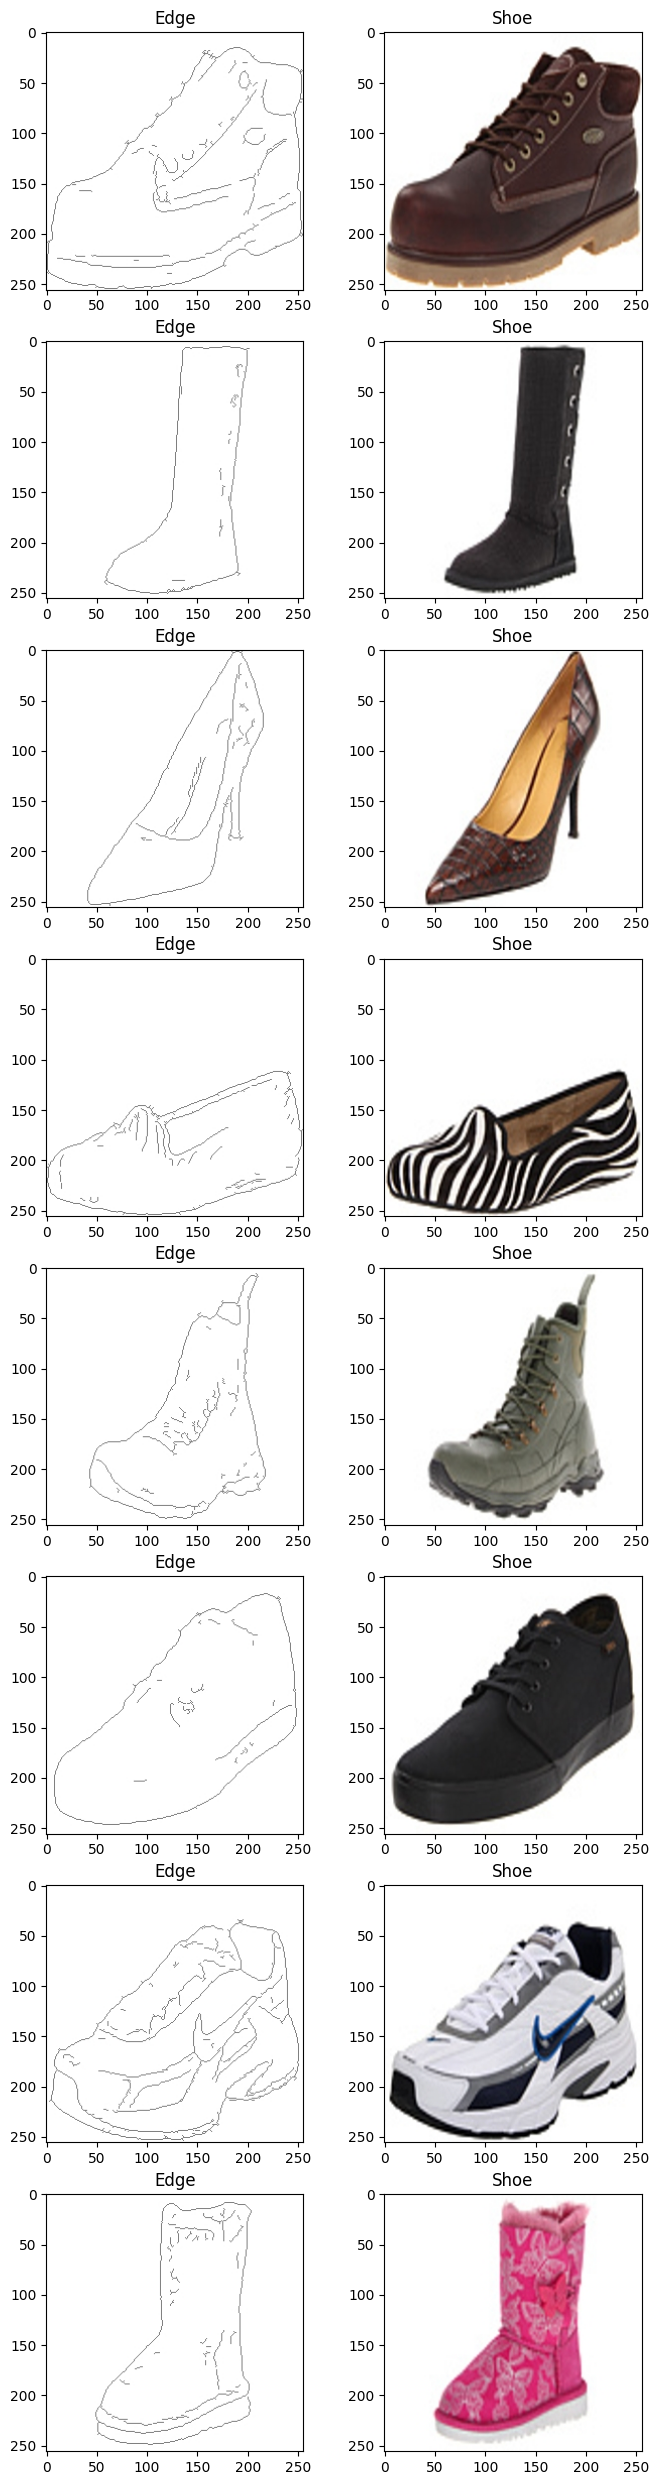

In [32]:
# diplaying a batch from the dataset
plt.figure(figsize=(8, 256))

for i in range(8):
    edge = (fixed_batch["edge"][i] * 0.5) + 0.5
    shoe = (fixed_batch["shoe"][i] * 0.5) + 0.5
    
    plt.subplot(64, 2, 2*i + 1)
    plt.title("Edge")
    plt.imshow(edge.permute(1,2,0))

    plt.subplot(64, 2, 2*i + 2)
    plt.title("Shoe")
    plt.imshow(shoe.permute(1,2,0))

plt.show()

In [33]:
fixed_batch = {
    "edge": fixed_batch["edge"].to(device),
    "shoe": fixed_batch["shoe"].to(device)
}

In [36]:
DiT.train()
n_epochs = 20
global_step = 0
train_losses = []
best_loss = float("inf")

generated = generate_images(
    fixed_batch,
    DiT,
    num_inference_steps=100
)

save_monitor_image(
    fixed_batch,
    generated,
    step=global_step
)
print(f"\nMonitoring at step {global_step}")

for epoch in range(n_epochs):
    
    progress_bar = tqdm(train_loader)
    progress_bar.set_description(f"Epoch {epoch+1}")
    epoch_loss = 0
    
    for batch in progress_bar:
        # Load data inputs
        edge = batch["edge"].to(device)
        shoe = batch["shoe"].to(device)
        batch_size = edge.shape[0]
        
        # Convert the shoe image to the latent space
        with torch.no_grad():
            shoe_latents = encode_img(shoe)

        # Initialize noise with the same shape of the latents of the target image as it will be added to it 
        noise = torch.randn_like(shoe_latents)
        # Initialize a random timesteps for this batch of images, so each image in the batch will take a random timestep and this will make the model deal with images in different level of noise helping it to generalize well
        timesteps = torch.randint(
            0,
            noise_scheduler.config.num_train_timesteps,
            (batch_size,),
            device=device
        ).long()
        # Use the noise scheduler to add noise to the latent representation of the shoe images in the timesteps that are initialized randomly in the previous step 
        noisy_latents = noise_scheduler.add_noise(
            shoe_latents,
            noise,
            timesteps
        )

        # Get CLIP embeddings of the edge image as these will be the conditions
        with torch.no_grad():
            clip_embeddings = get_clip_embeddings(edge)

        # Give the model the inputs: noisy latents, timestep, and clip embeddings of the edge image. It will predict the noise added to the input latents while taking into consederation the conditions which are the clip embeddings of the edge image
        pred_noise = DiT(
            noisy_latents,
            timesteps,
            clip_embeddings
        )
        #take only the channels that corresponds to the noise prediction because the rest of channels are for the variance 
        pred_noise = pred_noise[:, :4]

        # Compute loss value between the predicted noise and the real noise
        loss = criterion(pred_noise, noise)
        epoch_loss += loss.item()

        # backpropagation and optimizer step
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        global_step += 1

        if global_step % 500 == 0:
            generated = generate_images(
                fixed_batch,
                DiT,
                num_inference_steps=100
            )
            
            save_monitor_image(
                fixed_batch,
                generated,
                step=global_step
            )
            print(f"\nMonitoring at step {global_step}")
            
    epoch_loss /= len(train_loader) # take the average loss from all batches in the epoch
    train_losses.append(epoch_loss)
    print(f"Epoch {epoch+1} | Loss = {epoch_loss}")
    torch.save(train_losses, "DiT_base_loss_history.pt") # save losses to plot the curve later 

    # Save BEST model since the training is unstable
    if epoch_loss < best_loss:
        best_loss = epoch_loss
        print(f"New best model at epoch {epoch+1}")

        torch.save({
            "epoch": epoch + 1,
            "DiT_state_dict": DiT.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "loss": best_loss,
        }, "DiT_best_checkpoint.pth")
        
    # save last model checkpoints
    torch.save({
        "epoch": epoch + 1,
        "DiT_state_dict": DiT.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
    }, "DiT_last_checkpoint.pth")


Monitoring at step 0


Epoch 1:  40%|████      | 500/1250 [10:07<1:55:29,  9.24s/it]


Monitoring at step 500


Epoch 1:  80%|████████  | 1000/1250 [20:19<38:12,  9.17s/it] 


Monitoring at step 1000


...


Monitoring at step 24000


Epoch 20:  60%|██████    | 750/1250 [15:32<1:16:10,  9.14s/it]


Monitoring at step 24500


Epoch 20: 100%|██████████| 1250/1250 [25:46<00:00,  1.24s/it] 


Monitoring at step 25000
Epoch 20 | Loss = 0.08330309117436409
New best model at epoch 20


## DiT Second Variation (Edge-Latents-Conditioning)

In the first modification, the DiT model was conditioned using CLIP embeddings extracted from the edge image. The edge image was passed through a pretrained CLIP image encoder, and the resulting feature vector was projected into the DiT embedding space before being combined with the timestep embedding through adaptive Layer Normalization (adaLN).

Although this approach provides useful semantic information about the input sketch, it has an important limitation: the CLIP embedding is a global representation of the entire image and does not explicitly preserve its spatial structure. As a result, the generated image may match the semantic content of the sketch while failing to accurately preserve the locations, proportions, and geometry of its edges.

To address this limitation, a second conditioning strategy was investigated by directly conditioning the DiT model on the latent representation of the edge image instead of its CLIP embedding. The second modification conditions the model directly on the latent representation of the edge image.

The edge image is encoded using the pretrained VAE to obtain a latent representation of size **(4 × 32 × 32)**. During training, the target shoe image is also encoded into its latent representation, and Gaussian noise is added to produce the noisy target latent. The edge latent and the noisy target latent are then concatenated along the channel dimension, resulting in an input tensor of size **(8 × 32 × 32)**. To process this concatenated input, the **x_embedder** of the DiT model is modified by changing the input channels of its convolutional projection from **4 to 8**, while keeping the remainder of the DiT architecture unchanged.

Unlike the CLIP embedding, the VAE latent representation preserves the spatial organization of the original image. Each location in the latent tensor corresponds to a specific spatial region of the original image.

Therefore, when the edge latent is concatenated with the noisy target latent, the transformer receives aligned structural information for every spatial location. Instead of only learning what object should be generated, the model also learns where every structural component is located.

In [35]:
# Loading the model from the file where updates saved
from DiT.models_edge_latents_conditioning import DiT_XL_2
DiT = DiT_XL_2(input_size=32).to(device)
DiT

DiT(
  (x_embedder): PatchEmbed(
    (proj): Conv2d(8, 1152, kernel_size=(2, 2), stride=(2, 2))
    (norm): Identity()
  )
  (t_embedder): TimestepEmbedder(
    (mlp): Sequential(
      (0): Linear(in_features=256, out_features=1152, bias=True)
      (1): SiLU()
      (2): Linear(in_features=1152, out_features=1152, bias=True)
    )
  )
  (blocks): ModuleList(
    (0-27): 28 x DiTBlock(
      (norm1): LayerNorm((1152,), eps=1e-06, elementwise_affine=False)
      (attn): Attention(
        (qkv): Linear(in_features=1152, out_features=3456, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (norm): Identity()
        (proj): Linear(in_features=1152, out_features=1152, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (norm2): LayerNorm((1152,), eps=1e-06, elementwise_affine=False)
      (mlp): Mlp(
        (fc1): Linear(in_features=1152, out_features=4608, bias=True)
        (act): GELU

In [36]:
# Freeze the parameters of VAE from training
vae.eval()
for p in vae.parameters():
    p.requires_grad = False

In [37]:
# Identify the loss function 
criterion = torch.nn.MSELoss()
# Identify the optimizer
optimizer = torch.optim.AdamW(
    DiT.parameters(),
    lr=5e-5,
    weight_decay=1e-4 # for regularization
)

In [38]:
@torch.no_grad()
def generate_images(
    fixed_batch,
    dit_model,
    num_inference_steps=100,
):
    """
    edge_images: (B,3,256,256) in [-1,1]

    returns:
        generated_images: (B,3,256,256) in [-1,1]
    """

    dit_model.eval()

    edge_images = fixed_batch["edge"]
    batch_size = edge_images.shape[0]
    device = edge_images.device

    # Start from pure Gaussian noise
    latents = torch.randn(batch_size, 4, 32, 32, device=device)

    # Match SD latent scaling
    latents = latents * noise_scheduler.init_noise_sigma

    edge_latents = encode_img(edge_images)

    # Reverse diffusion loop
    noise_scheduler.set_timesteps(num_inference_steps, device=device)

    for t in noise_scheduler.timesteps:

        timestep_batch = torch.full((batch_size,), t, device=device, dtype=torch.long)

        model_input = torch.cat([latents, edge_latents], dim=1)
        
        model_output = dit_model(
            model_input,
            timestep_batch
        )

        # keep only epsilon prediction
        pred_noise = model_output[:, :4]

        latents = noise_scheduler.step(
            pred_noise,
            t,
            latents
        ).prev_sample

    # Decode latents
    images = decode_latents(latents)
    images = images.clamp(-1, 1)

    dit_model.train()

    return images

In [25]:
DiT.train()
n_epochs = 20
global_step = 0
train_losses = []
best_loss = float("inf")

generated = generate_images(
    fixed_batch,
    DiT,
    num_inference_steps=100
)

save_monitor_image(
    fixed_batch,
    generated,
    step=global_step
)
print(f"\nMonitoring at step {global_step}")

for epoch in range(n_epochs):
    
    progress_bar = tqdm(train_loader)
    progress_bar.set_description(f"Epoch {epoch+1}")
    epoch_loss = 0
    
    for batch in progress_bar:
        # Load data inputs
        edge = batch["edge"].to(device)
        shoe = batch["shoe"].to(device)
        batch_size = edge.shape[0]
        
        # Convert the shoe image to the latent space
        with torch.no_grad():
            edge_latents = encode_img(edge)
            shoe_latents = encode_img(shoe)

        # Initialize noise with the same shape of the latents of the target image as it will be added to it 
        noise = torch.randn_like(shoe_latents)
        # Initialize a random timesteps for this batch of images, so each image in the batch will take a random timestep and this will make the model deal with images in different level of noise helping it to generalize well
        timesteps = torch.randint(
            0,
            noise_scheduler.config.num_train_timesteps,
            (batch_size,),
            device=device
        ).long()
        # Use the noise scheduler to add noise to the latent representation of the shoe images in the timesteps that are initialized randomly in the previous step 
        noisy_latents = noise_scheduler.add_noise(
            shoe_latents,
            noise,
            timesteps
        )

        model_input = torch.cat([noisy_latents, edge_latents], dim=1)
        
        # Give the model the inputs: noisy latents, timestep, and clip embeddings of the edge image. It will predict the noise added to the input latents while taking into consederation the conditions which are the clip embeddings of the edge image
        pred_noise = DiT(
            model_input,
            timesteps
        )
        #take only the channels that corresponds to the noise prediction because the rest of channels are for the variance 
        pred_noise = pred_noise[:, :4]

        # Compute loss value between the predicted noise and the real noise
        loss = criterion(pred_noise, noise)
        epoch_loss += loss.item()

        # backpropagation and optimizer step
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        global_step += 1

        if global_step % 500 == 0:
            generated = generate_images(
                fixed_batch,
                DiT,
                num_inference_steps=100
            )
            
            save_monitor_image(
                fixed_batch,
                generated,
                step=global_step
            )
            print(f"\nMonitoring at step {global_step}")
            
    epoch_loss /= len(train_loader) # take the average loss from all batches in the epoch
    train_losses.append(epoch_loss)
    print(f"Epoch {epoch+1} | Loss = {epoch_loss}")
    torch.save(train_losses, "DiT_base_loss_history.pt") # save losses to plot the curve later 

    # Save BEST model since the training is unstable
    if epoch_loss < best_loss:
        best_loss = epoch_loss
        print(f"New best model at epoch {epoch+1}")

        torch.save({
            "epoch": epoch + 1,
            "DiT_state_dict": DiT.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "loss": best_loss,
        }, "DiT_best_checkpoint.pth")
        
    # save last model checkpoints
    torch.save({
        "epoch": epoch + 1,
        "DiT_state_dict": DiT.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
    }, "DiT_last_checkpoint.pth")


Monitoring at step 0


Epoch 1:  40%|████      | 500/1250 [11:13<1:58:00,  9.44s/it]


Monitoring at step 500


Epoch 1:  80%|████████  | 1000/1250 [22:29<38:40,  9.28s/it] 


Monitoring at step 1000


...


Monitoring at step 24000


Epoch 20:  60%|██████    | 750/1250 [17:04<1:17:37,  9.32s/it]


Monitoring at step 24500


Epoch 20: 100%|██████████| 1250/1250 [28:20<00:00,  1.36s/it] 


Monitoring at step 25000
Epoch 20 | Loss = 0.07615277452282608


# Model Evaluation

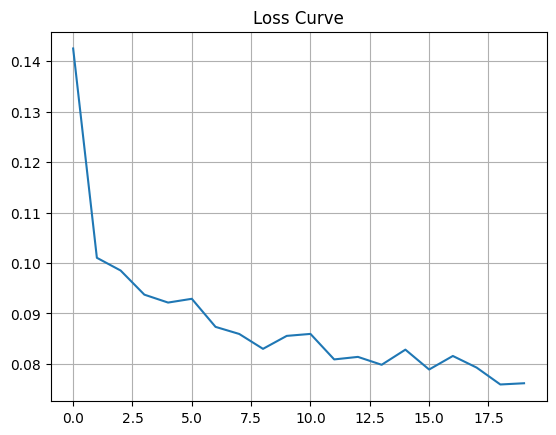

In [39]:
# Plot the loss curve of training
loss_curve = torch.load("DiT_loss_history.pt", map_location=device)
plt.plot(loss_curve)
plt.title("Loss Curve")
plt.grid(True)
plt.show()

In [40]:
# Load Best Model
checkpoint = torch.load("DiT_best_checkpoint.pth", map_location=device)
DiT.load_state_dict(checkpoint["DiT_state_dict"])
DiT.eval()
print(f"Epoch {checkpoint["epoch"]}")

Epoch 19


In [41]:
batch = next(iter(test_loader))
batch.keys()

dict_keys(['shoe', 'edge'])

In [42]:
# Use the model to genrate a batch of images
generated = generate_images(batch, DiT)

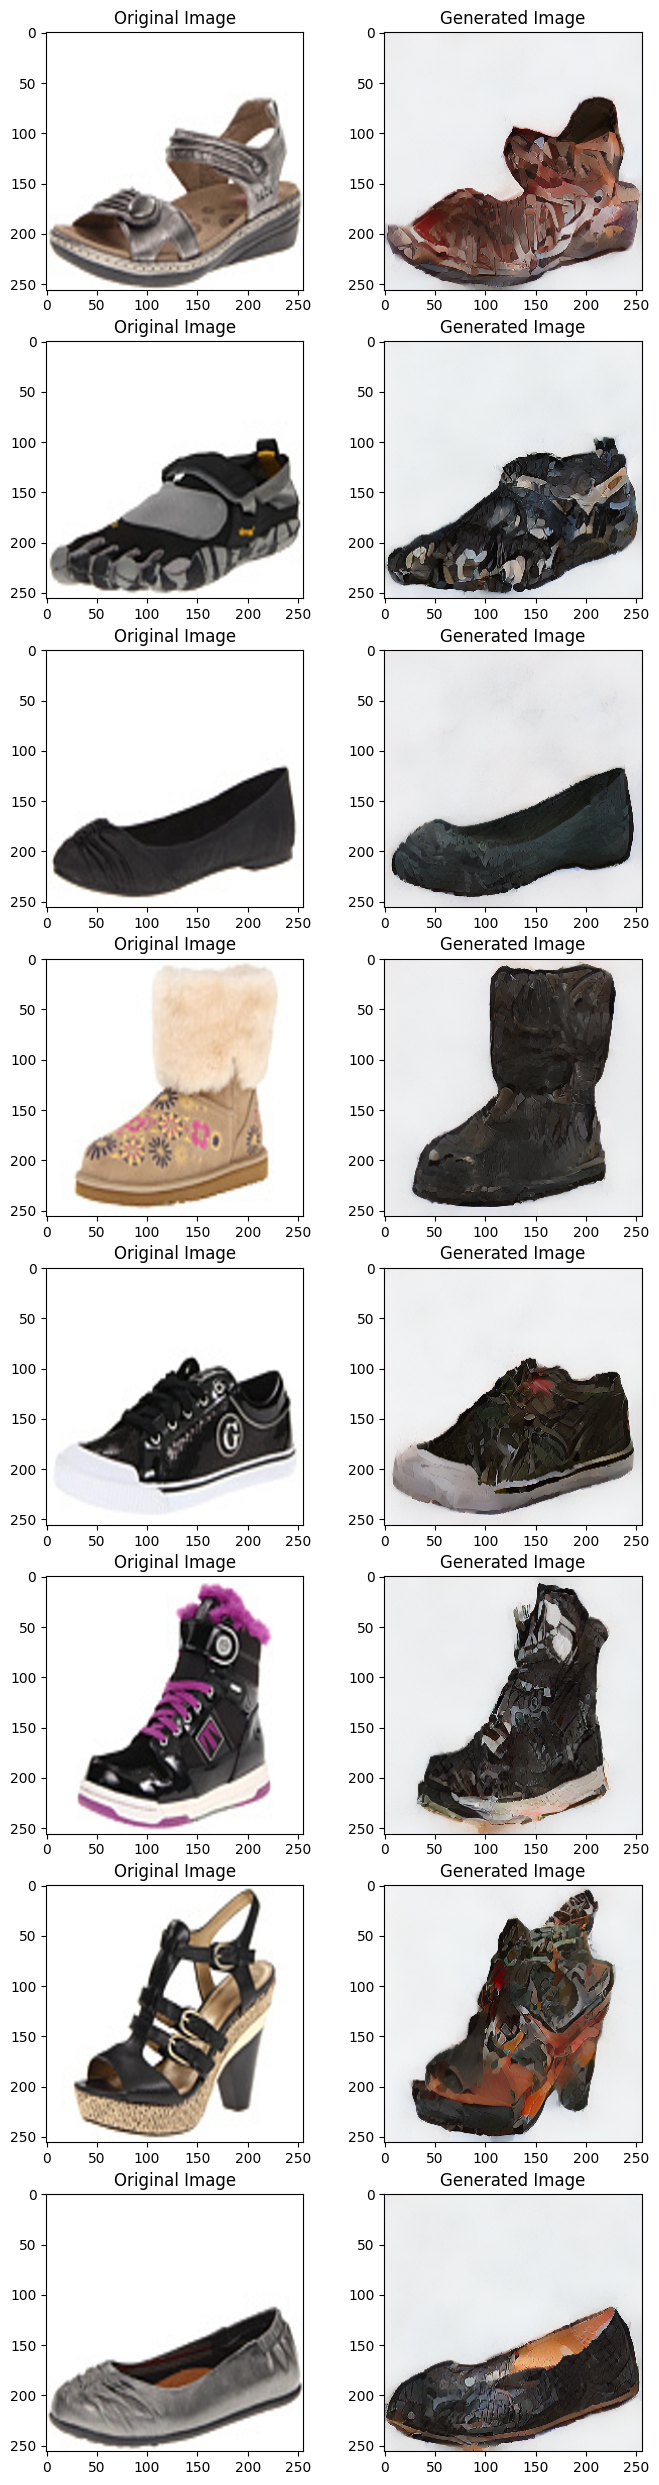

In [43]:
# diplaying aoriginal images and generated images
plt.figure(figsize=(8, 256))

for i in range(8):
    shoe = (batch["shoe"][i] * 0.5) + 0.5
    generated_image = (generated[i] * 0.5) + 0.5
    
    plt.subplot(64, 2, 2*i + 1)
    plt.title("Original Image")
    plt.imshow(shoe.permute(1,2,0).cpu())

    plt.subplot(64, 2, 2*i + 2)
    plt.title("Generated Image")
    plt.imshow(generated_image.permute(1,2,0).cpu())

plt.show()

### Quantitative Evaluation

In [45]:
# Normalize the range of pixels between [0,1] as expected by the SSIM and PSNR
test_shoes = (batch["shoe"] + 1) / 2
generated_images = (generated + 1) / 2

# Clamp
test_shoes = torch.clamp(test_shoes, 0, 1)
generated_images = torch.clamp(generated_images, 0, 1)

In [46]:
from torchmetrics.image import StructuralSimilarityIndexMeasure
from torchmetrics.image import PeakSignalNoiseRatio

generated_images = generated_images.cpu()
test_shoes = test_shoes.cpu()

ssim_metric = StructuralSimilarityIndexMeasure(data_range=1.0)
psnr_metric = PeakSignalNoiseRatio(data_range=1.0)

ssim_score = ssim_metric(generated_images, test_shoes)
psnr_score = psnr_metric(generated_images, test_shoes)

print("SSIM:", ssim_score.item())
print("PSNR:", psnr_score.item())

SSIM: 0.6678831577301025
PSNR: 13.102470397949219
